In [12]:
import pandas as pd

# Load the Excel files
food_prices = pd.read_excel('Food_Prices_for_Nutrition.xlsx')
food_insecurity = pd.read_excel('Food_Insecurity_nourishment_Indicators.xlsx')
health_indicators = pd.read_excel('health-relatedindicators.xlsx')
health_achievement = pd.read_excel('overall health achievement level.xlsx')

In [13]:
#Standardize Column Names and Country Names
# Rename 'Country Name' and 'Time' to 'Country' and 'Year' in food_prices and food_insecurity
food_prices.rename(columns={'Country Name': 'Country', 'Time': 'Year'}, inplace=True)
food_insecurity.rename(columns={'Country Name': 'Country', 'Time': 'Year'}, inplace=True)

# Rename 'year' to 'Year' in health_indicators and health_achievement
health_indicators.rename(columns={'year': 'Year'}, inplace=True)
health_achievement.rename(columns={'year': 'Year'}, inplace=True)

#  Standardize 'Viet Nam' to 'Vietnam' across all datasets
food_prices['Country'] = food_prices['Country'].replace('Viet Nam', 'Vietnam')
food_insecurity['Country'] = food_insecurity['Country'].replace('Viet Nam', 'Vietnam')
health_indicators['Country'] = health_indicators['Country'].replace('Viet Nam', 'Vietnam')
health_achievement['Country'] = health_achievement['Country'].replace('Viet Nam', 'Vietnam')

In [14]:
# Check if the columns were renamed successfully
print(food_prices.columns)
print(food_insecurity.columns)
print(health_indicators.columns)
print(health_achievement.columns)


Index(['Country', 'Country Code', 'Year', 'Time Code',
       'Affordability of a healthy diet: ratio of cost to the food poverty line [CoHD_pov]',
       'Cost of a healthy diet [CoHD]',
       'Percent of the population who cannot afford a healthy diet [CoHD_headcount]'],
      dtype='object')
Index(['Country', 'Country Code', 'Series Name', 'Series Code',
       '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]',
       '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]',
       '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]',
       '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]',
       '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]',
       '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]'],
      dtype='object')
Index(['id', 'Country', 'Year', 'sdg3_matmort', 'sdg3_neonat', 'sdg3_u5mort',
       'sdg3_tb', 'sdg3_hiv', 'sdg3_ncds', 'sdg3_lifee', 'sdg3_fertility',
       'sdg3_

In [15]:
# Select the 10 selected countries
selected_countries = ['Nigeria', 'Nepal', 'India', 'China', 'Chile', 'Finland', 'Australia', 'Canada', 'Vietnam', 'Italy']

# Filter data for the selected countries
selected_country_food_prices = food_prices[food_prices['Country'].isin(selected_countries)].reset_index(drop=True)
selected_country_food_insecurity = food_insecurity[food_insecurity['Country'].isin(selected_countries)].reset_index(drop=True)
selected_country_health_indicators = health_indicators[health_indicators['Country'].isin(selected_countries)].reset_index(drop=True)
selected_country_health_achievement = health_achievement[health_achievement['Country'].isin(selected_countries)].reset_index(drop=True)

# Display the newly created DataFrames
print("Food Prices for Selected Countries:")
print(selected_country_food_prices.head())

print("\nFood Insecurity for Selected Countries:")
print(selected_country_food_insecurity.head())

print("\nHealth Indicators for Selected Countries:")
print(selected_country_health_indicators.head())

print("\nHealth Achievement for Selected Countries:")
print(selected_country_health_achievement.head())



Food Prices for Selected Countries:
     Country Country Code  Year Time Code  \
0  Australia          AUS  2017    YR2017   
1  Australia          AUS  2018    YR2018   
2  Australia          AUS  2019    YR2019   
3  Australia          AUS  2020    YR2020   
4  Australia          AUS  2021    YR2021   

  Affordability of a healthy diet: ratio of cost to the food poverty line [CoHD_pov]  \
0                                               0.21                                   
1                                               0.21                                   
2                                               0.21                                   
3                                               0.22                                   
4                                               0.23                                   

  Cost of a healthy diet [CoHD]  \
0                          2.33   
1                          2.36   
2                           2.4   
3                       

In [16]:
# Handle Missing Data
# Check for missing values in each DataFrame for the 10 selected countries
# Replace periods (or any other placeholders) with NaN
selected_country_food_prices.replace('..', pd.NA, inplace=True)
selected_country_food_insecurity.replace('..', pd.NA, inplace=True)
selected_country_health_indicators.replace('..', pd.NA, inplace=True)
selected_country_health_achievement.replace('..', pd.NA, inplace=True)

# Check for missing values again
print("Missing values in Food Prices for selected countries:")
print(selected_country_food_prices.isnull().sum())

print("\nMissing values in Food Insecurity for selected countries:")
print(selected_country_food_insecurity.isnull().sum())

print("\nMissing values in Health Indicators for selected countries:")
print(selected_country_health_indicators.isnull().sum())

print("\nMissing values in Health Achievement for selected countries:")
print(selected_country_health_achievement.isnull().sum())


Missing values in Food Prices for selected countries:
Country                                                                               0
Country Code                                                                          0
Year                                                                                  0
Time Code                                                                             0
Affordability of a healthy diet: ratio of cost to the food poverty line [CoHD_pov]    0
Cost of a healthy diet [CoHD]                                                         0
Percent of the population who cannot afford a healthy diet [CoHD_headcount]           0
dtype: int64

Missing values in Food Insecurity for selected countries:
Country           0
Country Code      0
Series Name       0
Series Code       0
2000 [YR2000]    30
2001 [YR2001]    20
2002 [YR2002]    20
2003 [YR2003]    20
2004 [YR2004]    20
2005 [YR2005]    20
2006 [YR2006]    20
2007 [YR2007]    20
2008 [YR2008]    2

In [17]:
#Handle missing value DataFrame selected_country_health_indicators
# Drop column 'sdg3_hiv' selected_country_health_indicators
selected_country_health_indicators.drop(columns=['sdg3_hiv'], inplace=True)
# Fill missing (NaN) values in the DataFrame selected_country_health_indicators using the median
numeric_columns = selected_country_health_indicators.select_dtypes(include=['float64', 'int64']).columns

# Fill NaN values with the median for numeric columns
selected_country_health_indicators[numeric_columns] = selected_country_health_indicators[numeric_columns].fillna(selected_country_health_indicators[numeric_columns].median())

# Check again if there are any remaining missing values
print("\nMissing values after filling with median:")
print(selected_country_health_indicators.isnull().sum())



Missing values after filling with median:
id                0
Country           0
Year              0
sdg3_matmort      0
sdg3_neonat       0
sdg3_u5mort       0
sdg3_tb           0
sdg3_ncds         0
sdg3_lifee        0
sdg3_fertility    0
sdg3_births       0
sdg3_vac          0
dtype: int64


In [18]:
#Handle missing value DataFrame selected_country_food_insecurity
# Check the columns in your DataFrame
print(selected_country_food_insecurity.columns)



Index(['Country', 'Country Code', 'Series Name', 'Series Code',
       '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]',
       '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]',
       '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]',
       '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]',
       '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]',
       '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]'],
      dtype='object')


In [19]:
import pandas as pd

# Reshape the DataFrame using melt
df_long = selected_country_food_insecurity.melt(
    id_vars=['Country', 'Country Code', 'Series Name', 'Series Code'],  # Keep these columns unchanged
    var_name='Year',  # The column where the year values will go
    value_name='Value'  # The column where the actual data values will go
)

# Extract just the 4-digit year from the 'Year' column (like '2000' from '2000 [YR2000]')
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})')

# Pivot the DataFrame to get one row per Country and Year, with the series names as separate columns
df_pivot = df_long.pivot_table(
    index=['Country', 'Country Code', 'Year'],  # Index by Country, Country Code, and Year
    columns='Series Name',  # Use Series Name as columns
    values='Value'  # Fill values based on 'Value'
).reset_index()

# Remove unnecessary pivot column name
df_pivot.columns.name = None

# Renaming columns for clarity based on your Series Name
df_pivot.rename(columns={
    'Prevalence of moderate or severe food insecurity in the population (%)': 'Prevalence of moderate or severe food insecurity',
    'Prevalence of severe food insecurity in the population (%)': 'Prevalence of severe food insecurity',
    'Prevalence of undernourishment (% of population)': 'Prevalence of undernourishment',
    'Current health expenditure (% of GDP)': 'Current health expenditure',
    'Domestic general government health expenditure (% of GDP)': 'Domestic general government health expenditure',
    'Domestic private health expenditure (% of current health expenditure)': 'Domestic private health expenditure'
}, inplace=True)

# Display the resulting DataFrame
print(df_pivot.head())


     Country Country Code  Year Current health expenditure  \
0  Australia          AUS  2000                   7.594123   
1  Australia          AUS  2001                   7.678099   
2  Australia          AUS  2002                    7.87627   
3  Australia          AUS  2003                   7.880872   
4  Australia          AUS  2004                   8.087086   

  Domestic general government health expenditure  \
0                                       5.455338   
1                                        5.45978   
2                                       5.666007   
3                                       5.622313   
4                                       5.797398   

  Domestic private health expenditure  \
0                           28.163677   
1                            28.89152   
2                           28.062311   
3                           28.658747   
4                           28.312897   

  Prevalence of moderate or severe food insecurity  \
0            

In [20]:
# Renaming the reshaped DataFrame to 'selected_country_food_insecurity_new_structure'
selected_country_food_insecurity_new_structure = df_pivot

# Checking if the new structure is applied correctly
selected_country_food_insecurity_new_structure.head()  # Display the first few rows of the new structure



,Country,Country Code,Year,Current health expenditure,Domestic general government health expenditure,Domestic private health expenditure,Prevalence of moderate or severe food insecurity,Prevalence of severe food insecurity,Prevalence of undernourishment
0,Australia,AUS,2000,7.594123,5.455338,28.163677,NaN,NaN,NaN
1,Australia,AUS,2001,7.678099,5.45978,28.89152,NaN,NaN,2.5
2,Australia,AUS,2002,7.87627,5.666007,28.062311,NaN,NaN,2.5
3,Australia,AUS,2003,7.880872,5.622313,28.658747,NaN,NaN,2.5
4,Australia,AUS,2004,8.087086,5.797398,28.312897,NaN,NaN,2.5


In [21]:
# Convert columns to numeric
selected_country_food_insecurity_new_structure['Prevalence of moderate or severe food insecurity'] = pd.to_numeric(
    selected_country_food_insecurity_new_structure['Prevalence of moderate or severe food insecurity'], errors='coerce'
)
selected_country_food_insecurity_new_structure['Prevalence of severe food insecurity'] = pd.to_numeric(
    selected_country_food_insecurity_new_structure['Prevalence of severe food insecurity'], errors='coerce'
)
selected_country_food_insecurity_new_structure['Prevalence of undernourishment'] = pd.to_numeric(
    selected_country_food_insecurity_new_structure['Prevalence of undernourishment'], errors='coerce'
)

#  fill missing values for all numeric columns
numeric_columns = selected_country_food_insecurity_new_structure.select_dtypes(include='number').columns

# Apply median fill to the numeric columns
selected_country_food_insecurity_new_structure[numeric_columns] = selected_country_food_insecurity_new_structure[numeric_columns].fillna(
    selected_country_food_insecurity_new_structure[numeric_columns].median()
)

# Check if any missing values remain
print(selected_country_food_insecurity_new_structure.isnull().sum())

print(selected_country_food_insecurity_new_structure.head())



Country                                             0
Country Code                                        0
Year                                                0
Current health expenditure                          0
Domestic general government health expenditure      1
Domestic private health expenditure                 1
Prevalence of moderate or severe food insecurity    0
Prevalence of severe food insecurity                0
Prevalence of undernourishment                      0
dtype: int64
     Country Country Code  Year Current health expenditure  \
0  Australia          AUS  2000                   7.594123   
1  Australia          AUS  2001                   7.678099   
2  Australia          AUS  2002                    7.87627   
3  Australia          AUS  2003                   7.880872   
4  Australia          AUS  2004                   8.087086   

  Domestic general government health expenditure  \
0                                       5.455338   
1                       

In [22]:
# Convert the 'Year' column to integer type for all DataFrames
selected_country_food_prices['Year'] = selected_country_food_prices['Year'].astype(int)
selected_country_health_indicators['Year'] = selected_country_health_indicators['Year'].astype(int)
selected_country_food_insecurity_new_structure['Year'] = selected_country_food_insecurity_new_structure['Year'].astype(int)
selected_country_health_achievement['Year'] = selected_country_health_achievement['Year'].astype(int)

# Check the data type of the 'Year' column
print(selected_country_food_prices.dtypes)
print(selected_country_health_indicators.dtypes)
print(selected_country_food_insecurity_new_structure.dtypes)
print(selected_country_health_achievement.dtypes)


# Merge  DataFrame 
merged_data = pd.merge(selected_country_food_prices, selected_country_health_indicators, on=['Country', 'Year'], how='inner')
merged_data = pd.merge(merged_data, selected_country_food_insecurity_new_structure, on=['Country', 'Year'], how='inner')
merged_data = pd.merge(merged_data, selected_country_health_achievement, on=['Country', 'Year'], how='inner')

# Check after merging
print(merged_data.head())
print(merged_data.isnull().sum())  



Country                                                                               object
Country Code                                                                          object
Year                                                                                   int64
Time Code                                                                             object
Affordability of a healthy diet: ratio of cost to the food poverty line [CoHD_pov]    object
Cost of a healthy diet [CoHD]                                                         object
Percent of the population who cannot afford a healthy diet [CoHD_headcount]           object
dtype: object
id                 object
Country            object
Year                int64
sdg3_matmort      float64
sdg3_neonat       float64
sdg3_u5mort       float64
sdg3_tb           float64
sdg3_ncds         float64
sdg3_lifee        float64
sdg3_fertility    float64
sdg3_births       float64
sdg3_vac          float64
dtype: object
Country  

In [23]:
# Fill missing values with the median value of each column
merged_data['Domestic general government health expenditure'].fillna(merged_data['Domestic general government health expenditure'].median(), inplace=True)
merged_data['Domestic private health expenditure'].fillna(merged_data['Domestic private health expenditure'].median(), inplace=True)

# Check again after filling missing values
print(merged_data.isnull().sum())


Country                                                                               0
Country Code_x                                                                        0
Year                                                                                  0
Time Code                                                                             0
Affordability of a healthy diet: ratio of cost to the food poverty line [CoHD_pov]    0
Cost of a healthy diet [CoHD]                                                         0
Percent of the population who cannot afford a healthy diet [CoHD_headcount]           0
id_x                                                                                  0
sdg3_matmort                                                                          0
sdg3_neonat                                                                           0
sdg3_u5mort                                                                           0
sdg3_tb                         

/var/folders/fc/m91qtdls7mld56zp96k3mm0c0000gn/T/ipykernel_3613/384869168.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_data['Domestic general government health expenditure'].fillna(merged_data['Domestic general government health expenditure'].median(), inplace=True)
/var/folders/fc/m91qtdls7mld56zp96k3mm0c0000gn/T/ipykernel_3613/384869168.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead.

In [93]:
import pandas as pd

# Select the key variables
columns_of_interest = ['Cost of a healthy diet [CoHD]', 
                       'Prevalence of moderate or severe food insecurity', 
                       'Prevalence of undernourishment', 
                       'sdg3_lifee', 
                       'sdg3_matmort', 
                       'Domestic general government health expenditure']

# Calculate mean, min, and max for the selected columns
summary_stats = merged_data[columns_of_interest].agg(['mean', 'min', 'max'])

# Rename the index and columns for presentation
summary_stats.index = ['Mean', 'Minimum', 'Maximum']
summary_stats.columns = ['Cost of a Healthy Diet (USD)', 
                         'Prevalence of Moderate or Severe Food Insecurity (%)', 
                         'Prevalence of Undernourishment (% of population)', 
                         'Life Expectancy (years)', 
                         'Maternal Mortality Rate (per 100,000 live births)', 
                         'Government Health Expenditure (% of GDP)']

# Display the summary table
print(summary_stats)



         Cost of a Healthy Diet (USD)  \
Mean                         3.136604   
Minimum                      2.330000   
Maximum                      4.540000   

         Prevalence of Moderate or Severe Food Insecurity (%)  \
Mean                                             16.660377      
Minimum                                           5.000000      
Maximum                                          69.700000      

         Prevalence of Undernourishment (% of population)  \
Mean                                             5.178302   
Minimum                                          2.500000   
Maximum                                         16.600000   

         Life Expectancy (years)  \
Mean                   75.529123   
Minimum                52.305000   
Maximum                84.526000   

         Maternal Mortality Rate (per 100,000 live births)  \
Mean                                            122.375566   
Minimum                                           2.940000  

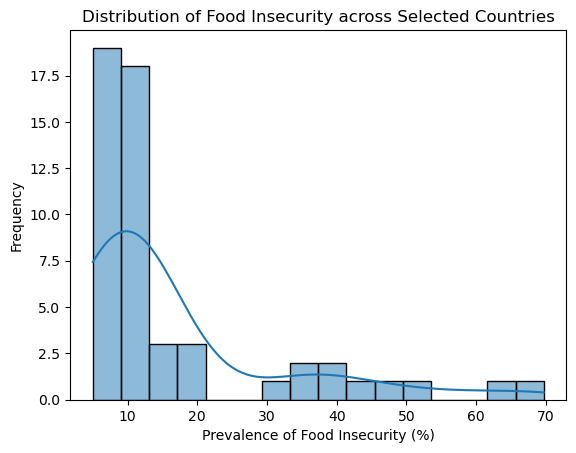

In [39]:
# Histogram: Distribution of Moderate or Severe Food Insecurity
sns.histplot(merged_data['Prevalence of moderate or severe food insecurity'], kde=True)
plt.title('Distribution of Food Insecurity across Selected Countries')
plt.xlabel('Prevalence of Food Insecurity (%)')
plt.ylabel('Frequency')
plt.show()


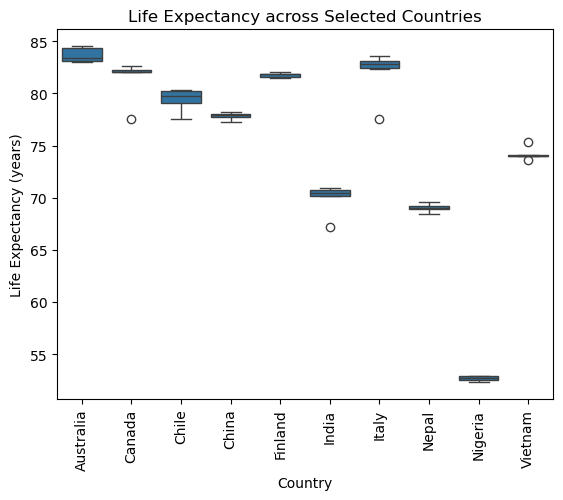

In [41]:
# Boxplot: Life Expectancy Comparison
sns.boxplot(x='Country', y='sdg3_lifee', data=merged_data)
plt.title('Life Expectancy across Selected Countries')
plt.xticks(rotation=90)
plt.ylabel('Life Expectancy (years)')
plt.show()


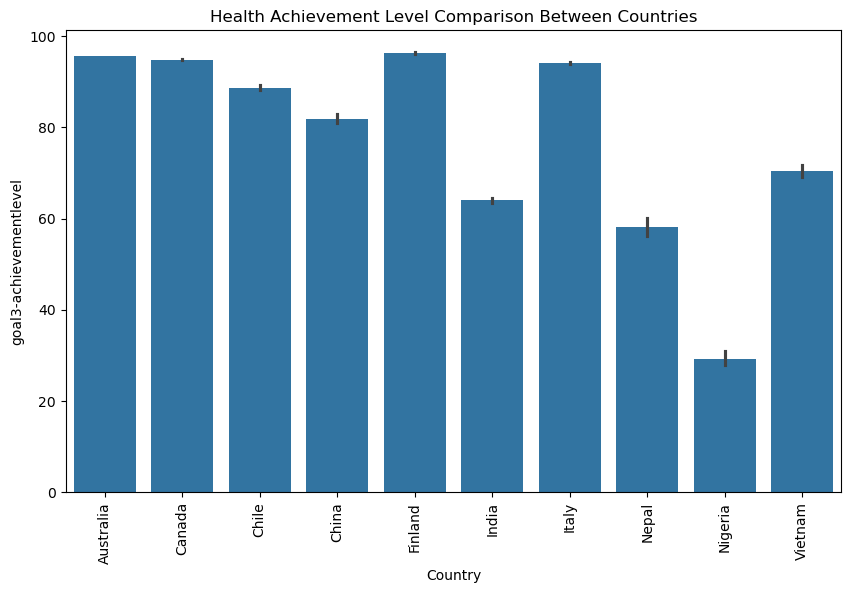

In [89]:
# Bar charts to compare health outcomes across countries
plt.figure(figsize=(10,6))
sns.barplot(x='Country', y='goal3-achievementlevel', data=merged_data)
plt.title('Health Achievement Level Comparison Between Countries')
plt.xticks(rotation=90)
plt.show()

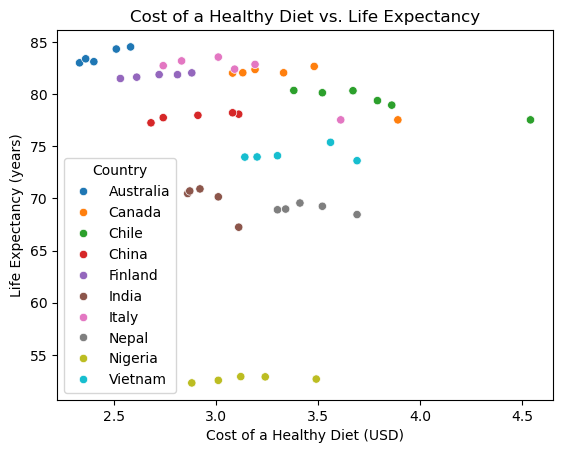

In [43]:
# Scatter plot: Cost of a Healthy Diet vs. Life Expectancy
sns.scatterplot(x='Cost of a healthy diet [CoHD]', y='sdg3_lifee', hue='Country', data=merged_data)
plt.title('Cost of a Healthy Diet vs. Life Expectancy')
plt.xlabel('Cost of a Healthy Diet (USD)')
plt.ylabel('Life Expectancy (years)')
plt.show()


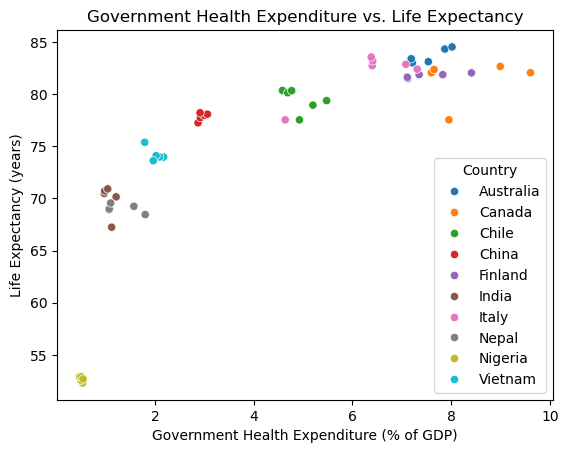

In [51]:
# Scatter plot: Government Health Expenditure vs. Life Expectancy
sns.scatterplot(x='Domestic general government health expenditure', y='sdg3_lifee', hue='Country', data=merged_data)
plt.title('Government Health Expenditure vs. Life Expectancy')
plt.xlabel('Government Health Expenditure (% of GDP)')
plt.ylabel('Life Expectancy (years)')
plt.show()



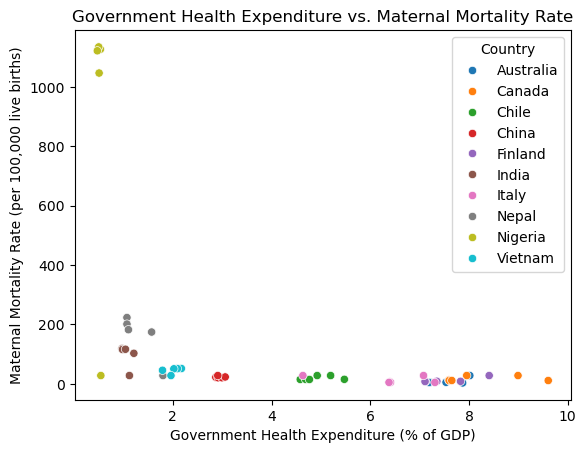

In [53]:
# Scatter plot: Government Health Expenditure vs. Maternal Mortality Rate
sns.scatterplot(x='Domestic general government health expenditure', y='sdg3_matmort', hue='Country', data=merged_data)
plt.title('Government Health Expenditure vs. Maternal Mortality Rate')
plt.xlabel('Government Health Expenditure (% of GDP)')
plt.ylabel('Maternal Mortality Rate (per 100,000 live births)')
plt.show()


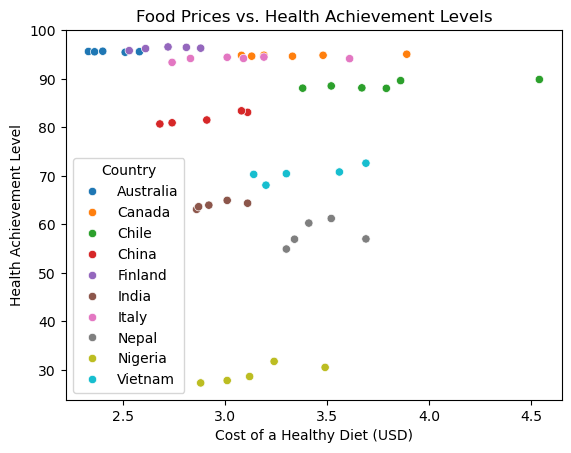

In [55]:
# Scatter plot: Food Prices vs. Health Achievement Levels
sns.scatterplot(x='Cost of a healthy diet [CoHD]', y='goal3-achievementlevel', hue='Country', data=merged_data)
plt.title('Food Prices vs. Health Achievement Levels')
plt.xlabel('Cost of a Healthy Diet (USD)')
plt.ylabel('Health Achievement Level')
plt.show()


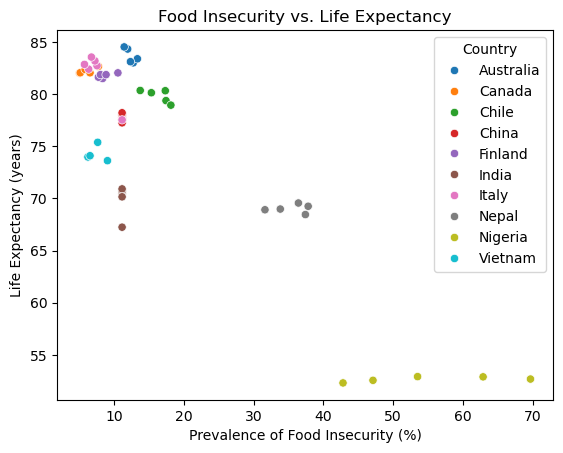

In [57]:
# Scatter plot: Food Insecurity vs. Life Expectancy
sns.scatterplot(x='Prevalence of moderate or severe food insecurity', y='sdg3_lifee', hue='Country', data=merged_data)
plt.title('Food Insecurity vs. Life Expectancy')
plt.xlabel('Prevalence of Food Insecurity (%)')
plt.ylabel('Life Expectancy (years)')
plt.show()


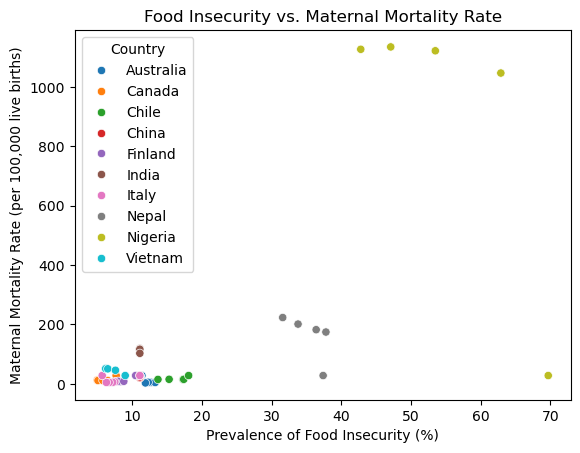

In [61]:
# Scatter plot: Food Insecurity vs. Maternal Mortality Rate
sns.scatterplot(x='Prevalence of moderate or severe food insecurity', y='sdg3_matmort', hue='Country', data=merged_data)
plt.title('Food Insecurity vs. Maternal Mortality Rate')
plt.xlabel('Prevalence of Food Insecurity (%)')
plt.ylabel('Maternal Mortality Rate (per 100,000 live births)')
plt.show()


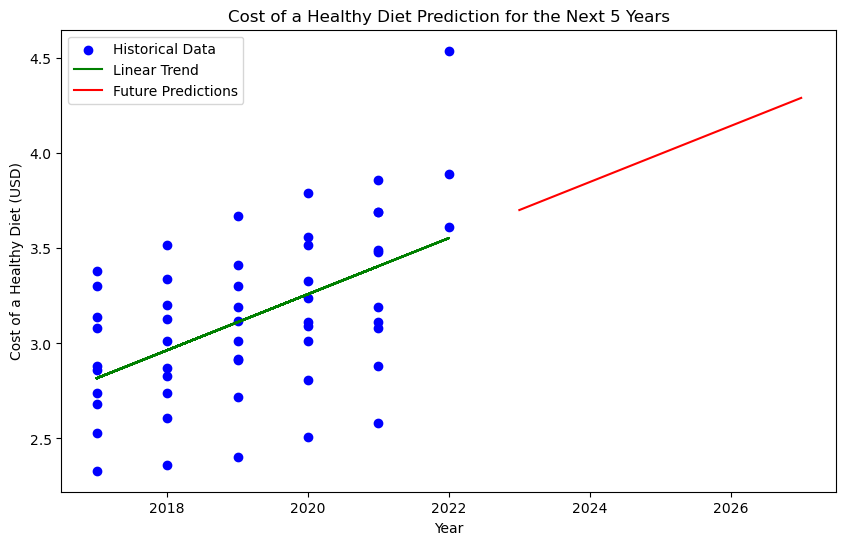

   Year  Predicted Cost of Healthy Diet
0  2023                        3.701663
1  2024                        3.849191
2  2025                        3.996719
3  2026                        4.144247
4  2027                        4.291774


In [83]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


df = merged_data[['Year', 'Cost of a healthy diet [CoHD]']].dropna()

# Define independent (X) and dependent variables (y)
X = df[['Year']]  # Independent variable: Year
y = df['Cost of a healthy diet [CoHD]']  # Dependent variable: Cost of a healthy diet

#  Train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

#  Predict future values for the next 5 years
future_years = pd.DataFrame({'Year': np.arange(df['Year'].max() + 1, df['Year'].max() + 6)})
future_predictions = model.predict(future_years)

# Visualize the prediction
plt.figure(figsize=(10,6))
plt.scatter(X, y, color='blue', label='Historical Data')
plt.plot(X, model.predict(X), color='green', label='Linear Trend')
plt.plot(future_years, future_predictions, color='red', label='Future Predictions')
plt.xlabel('Year')
plt.ylabel('Cost of a Healthy Diet (USD)')
plt.title('Cost of a Healthy Diet Prediction for the Next 5 Years')
plt.legend()
plt.show()

# Display future predictions
future_years['Predicted Cost of Healthy Diet'] = future_predictions
print(future_years)



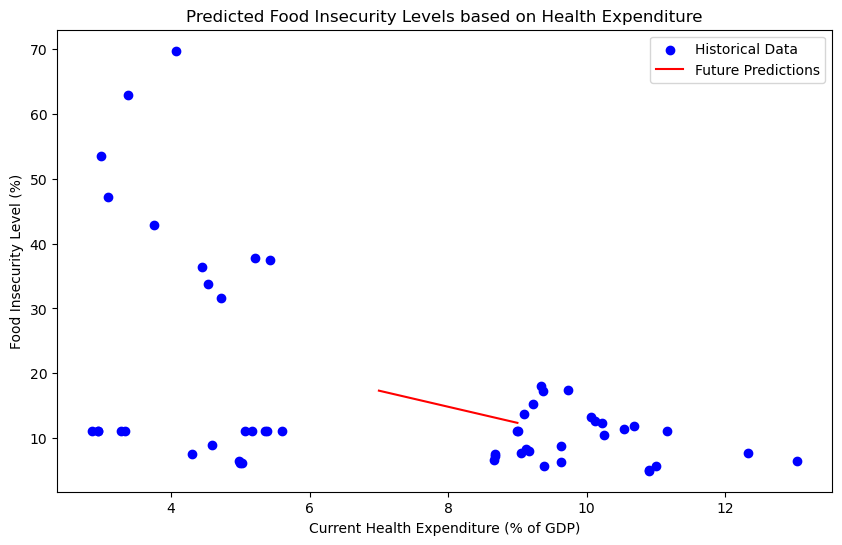

   Current health expenditure  Predicted Food Insecurity Level (%)
0                           7                            17.335009
1                           8                            14.854103
2                           9                            12.373197


In [85]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


df = merged_data[['Current health expenditure', 'Prevalence of moderate or severe food insecurity']].dropna()

# Define independent (X) and dependent variables (y)
X = df[['Current health expenditure']] 
y = df['Prevalence of moderate or severe food insecurity']  

#  Train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Predict future food insecurity for the next few years based on health expenditure projections
future_expenditure = pd.DataFrame({'Current health expenditure': [7, 8, 9]})  
future_predictions = model.predict(future_expenditure)

# Visualize historical and predicted data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Historical Data')
plt.plot(future_expenditure['Current health expenditure'], future_predictions, color='red', label='Future Predictions')
plt.xlabel('Current Health Expenditure (% of GDP)')
plt.ylabel('Food Insecurity Level (%)')
plt.title('Predicted Food Insecurity Levels based on Health Expenditure')
plt.legend()
plt.show()

# Display future predictions
future_expenditure['Predicted Food Insecurity Level (%)'] = future_predictions
print(future_expenditure)



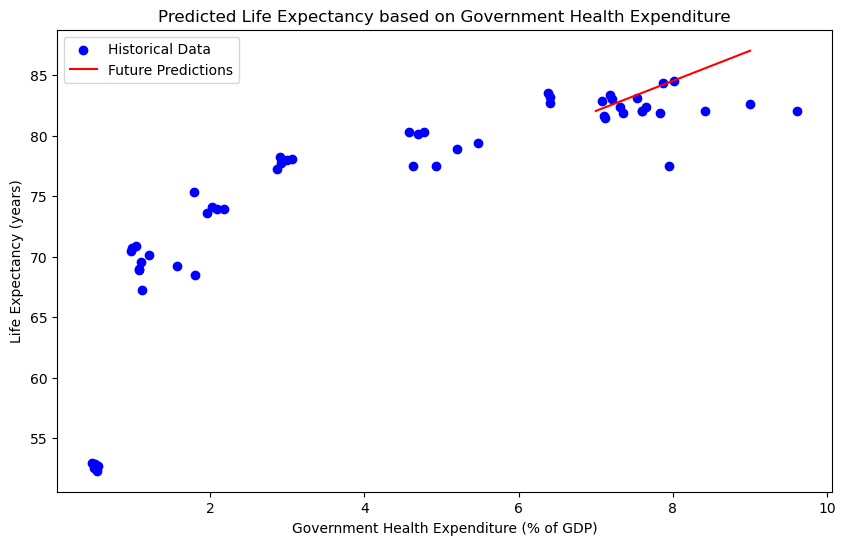

   Domestic general government health expenditure  \
0                                               7   
1                                               8   
2                                               9   

   Predicted Life Expectancy (years)  
0                          82.052867  
1                          84.543320  
2                          87.033773  


In [87]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


df = merged_data[['Domestic general government health expenditure', 'sdg3_lifee']].dropna()

#  Define independent (X) and dependent variables (y)
X = df[['Domestic general government health expenditure']]  
y = df['sdg3_lifee']  

#  Train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

#  Predict future life expectancy for the next few years based on government health expenditure projections
future_expenditure = pd.DataFrame({'Domestic general government health expenditure': [7, 8, 9]})  # Example future government health expenditure values
future_predictions = model.predict(future_expenditure)

# Visualize historical and predicted data
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Historical Data')
plt.plot(future_expenditure['Domestic general government health expenditure'], future_predictions, color='red', label='Future Predictions')
plt.xlabel('Government Health Expenditure (% of GDP)')
plt.ylabel('Life Expectancy (years)')
plt.title('Predicted Life Expectancy based on Government Health Expenditure')
plt.legend()
plt.show()

# Display future predictions
future_expenditure['Predicted Life Expectancy (years)'] = future_predictions
print(future_expenditure)
